# Session 4: Fuzzy Terms and Metric Mapping

This notebook converts raw forecast error metrics into linguistic labels for the explanation layer. 

Instead of relying on hard thresholds only, it uses fuzzy membership functions to represent gradual transitions between categories such as low, medium, and high error.

The goal is to map MAE and MPE into human-readable labels that better reflect uncertainty and overlap in model performance. 

By the end of this session, the notebook produces a working fuzzy mapping from metrics to labels like “high error” or “slight underprediction.”


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz

In [2]:
metrics = pd.DataFrame({
    "Model": ["Prophet", "ETS"],
    "MAE": [1404.139635, 2711.084216],
    "RMSE": [1803.539139, 3479.819623],
    "MAPE": [9.485486, 16.798173],
    "MPE": [-2.578297, 14.996615]
})

metrics

,Model,MAE,RMSE,MAPE,MPE
0,Prophet,1404.139635,1803.539139,9.485486,-2.578297
1,ETS,2711.084216,3479.819623,16.798173,14.996615


### Defining the Fuzzy Universes

In [3]:
mae_universe = np.arange(0, 4001, 1)
mpe_universe = np.arange(-25, 26, 1)

### Membership Functions

In [4]:
mae_low = fuzz.trimf(mae_universe, [0, 900, 1600])
mae_medium = fuzz.trimf(mae_universe, [1400, 2100, 2700])
mae_high = fuzz.trimf(mae_universe, [2500, 3300, 4000])

mpe_under = fuzz.trimf(mpe_universe, [-25, -6, -0.5])
mpe_neutral = fuzz.trimf(mpe_universe, [-1.0, 0, 1.0])
mpe_over = fuzz.trimf(mpe_universe, [0.5, 6, 25])


### Plotting membership functions

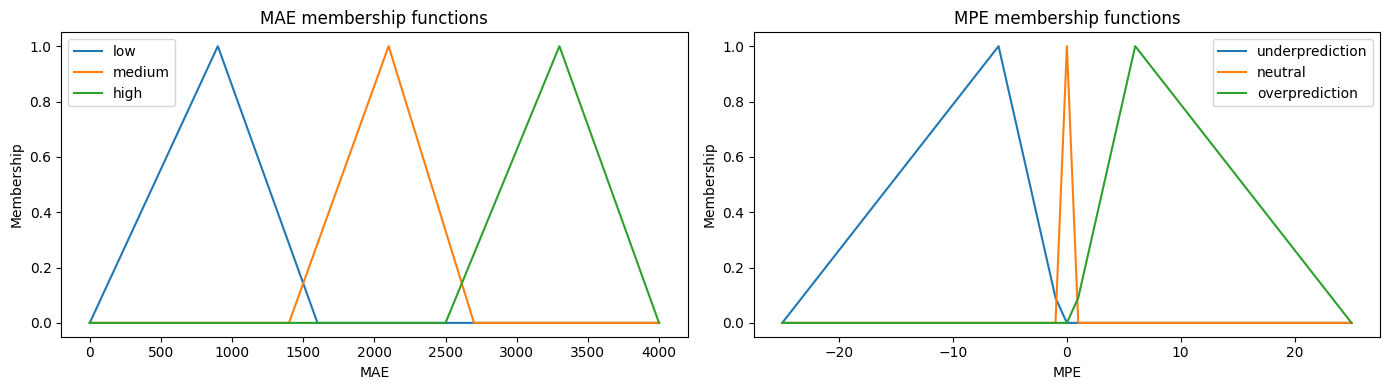

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mae_universe, mae_low, label="low")
axes[0].plot(mae_universe, mae_medium, label="medium")
axes[0].plot(mae_universe, mae_high, label="high")
axes[0].set_title("MAE membership functions")
axes[0].set_xlabel("MAE")
axes[0].set_ylabel("Membership")
axes[0].legend()

axes[1].plot(mpe_universe, mpe_under, label="underprediction")
axes[1].plot(mpe_universe, mpe_neutral, label="neutral")
axes[1].plot(mpe_universe, mpe_over, label="overprediction")
axes[1].set_title("MPE membership functions")
axes[1].set_xlabel("MPE")
axes[1].set_ylabel("Membership")
axes[1].legend()

plt.tight_layout()
plt.show()


### Mapping Function


In [6]:
def fuzzy_label_mae(value):
    low = fuzz.interp_membership(mae_universe, mae_low, value)
    medium = fuzz.interp_membership(mae_universe, mae_medium, value)
    high = fuzz.interp_membership(mae_universe, mae_high, value)

    scores = {
        "low error": low,
        "medium error": medium,
        "high error": high
    }
    return max(scores, key=scores.get), scores

def fuzzy_label_mpe(value):
    under = fuzz.interp_membership(mpe_universe, mpe_under, value)
    neutral = fuzz.interp_membership(mpe_universe, mpe_neutral, value)
    over = fuzz.interp_membership(mpe_universe, mpe_over, value)

    scores = {
        "slight underprediction": under,
        "neutral": neutral,
        "slight overprediction": over
    }
    return max(scores, key=scores.get), scores

def map_metrics_to_labels(mae, mpe):
    mae_label, mae_scores = fuzzy_label_mae(mae)
    mpe_label, mpe_scores = fuzzy_label_mpe(mpe)
    return pd.Series({
        "MAE_Label": mae_label,
        "MPE_Label": mpe_label,
        "Combined_Label": f"{mae_label}, {mpe_label}"
    })


### Applying to Models

In [7]:
labels = metrics.apply(lambda r: map_metrics_to_labels(r["MAE"], r["MPE"]), axis=1)
metrics = pd.concat([metrics, labels], axis=1)

metrics.round(3)

,Model,MAE,RMSE,MAPE,MPE,MAE_Label,MPE_Label,Combined_Label
0,Prophet,1404.140,1803.539,9.485,-2.578,low error,slight underprediction,"low error, slight underprediction"
1,ETS,2711.084,3479.820,16.798,14.997,high error,slight overprediction,"high error, slight overprediction"


### Readable Output

In [8]:
for _, row in metrics.iterrows():
    print(f"{row['Model']}: {row['Combined_Label']}")

Prophet: low error, slight underprediction
ETS: high error, slight overprediction


In [9]:
metrics.round(3).to_csv("data/session04_fuzzy_labels.csv", index=False)